# 0) Imports

In [16]:
# install the main library YFinance
!pip install yfinance

In [17]:
import sys
!{sys.executable} -m pip install pandas_datareader

In [18]:
# IMPORTS
import numpy as np
import pandas as pd

#Fin Data Sources
import yfinance as yf
import pandas_datareader as pdr

#Data viz
import plotly.graph_objs as go
import plotly.express as px

import time
from datetime import date


# 1) Understanding Data-Driven Decisions data pulls

In [19]:
end = date.today()
print(f'Year = {end.year}; month= {end.month}; day={end.day}')

start = date(year=end.year-70, month=end.month, day=end.day)
print(f'Period for indexes: {start} to {end} ')

Year = 2026; month= 9; day=8
Period for indexes: 1956-09-08 to 2026-09-08 


## 1.1) GDP

In [20]:
# Real Potential Gross Domestic Product (GDPPOT), Billions of Chained 2012 Dollars, QUARTERLY
# https://fred.stlouisfed.org/series/GDPPOT
gdppot = pdr.DataReader("GDPPOT", "fred", start=start)

In [21]:
gdppot['gdppot_us_yoy'] = gdppot.GDPPOT/gdppot.GDPPOT.shift(4)-1 # Shifting and calculation YOY Growth
gdppot['gdppot_us_qoq'] = gdppot.GDPPOT/gdppot.GDPPOT.shift(1)-1
gdppot.tail(15)

,GDPPOT,gdppot_us_yoy,gdppot_us_qoq
DATE,,,
2023-01-01,22229.482194,0.025405,0.006551
2023-04-01,22377.867950,0.026085,0.006675
2023-07-01,22527.570931,0.026560,0.006690
2023-10-01,22678.156520,0.026867,0.006685
2024-01-01,22828.945411,0.026967,0.006649
2024-04-01,22979.033391,0.026864,0.006574
2024-07-01,23126.896106,0.026604,0.006435
2024-10-01,23271.541687,0.026165,0.006254
2025-01-01,23414.656420,0.025657,0.006150


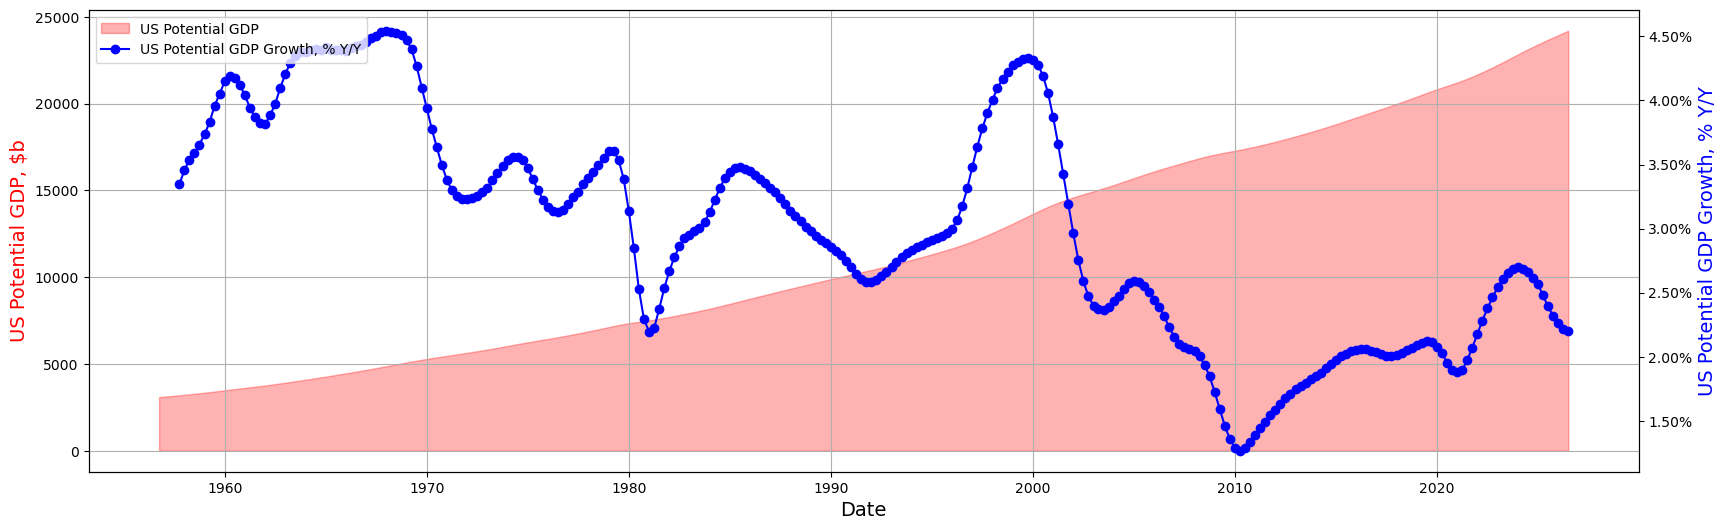

In [22]:
# Visuals GDPPOT
# https://cmdlinetips.com/2019/10/how-to-make-a-plot-with-two-different-y-axis-in-python-with-matplotlib/

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

fig, ax = plt.subplots(figsize=(20, 6))
plt.grid(True)

# Plotting area under US potential GDP curve
ax.fill_between(gdppot.index, gdppot.GDPPOT, color="red", alpha=0.3, label="US Potential GDP")

# Creating a secondary y-axis for GDP growth percentage
ax2 = ax.twinx()
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax2.plot(gdppot.gdppot_us_yoy, color="blue", marker="o", label="US Potential GDP Growth, % Y/Y")

# Setting labels and title
ax.set_xlabel("Date", fontsize=14)
ax.set_ylabel("US Potential GDP, $b", color="red", fontsize=14)
ax2.set_ylabel("US Potential GDP Growth, % Y/Y", color="blue", fontsize=14)

# Adding legend
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.show()

## 1.2) Inflation - CPI Core

In [23]:
# # "Core CPI index", MONTHLY
# https://fred.stlouisfed.org/series/CPILFESL
# The "Consumer Price Index for All Urban Consumers: All Items Less Food & Energy"
# is an aggregate of prices paid by urban consumers for a typical basket of goods, excluding food and energy.
# This measurement, known as "Core CPI," is widely used by economists because food and energy have very volatile prices.
cpilfesl = pdr.DataReader("CPILFESL", "fred", start=start)

In [24]:
cpilfesl.head()

,CPILFESL
DATE,
1957-01-01,28.5
1957-02-01,28.6
1957-03-01,28.7
1957-04-01,28.8
1957-05-01,28.8


In [25]:
cpilfesl['cpi_core_yoy'] = cpilfesl.CPILFESL/cpilfesl.CPILFESL.shift(12)-1
cpilfesl['cpi_core_mom'] = cpilfesl.CPILFESL/cpilfesl.CPILFESL.shift(1)-1

cpilfesl.tail(13)

,CPILFESL,cpi_core_yoy,cpi_core_mom
DATE,,,
2025-07-01,328.682,0.030545,0.003125
2025-08-01,329.700,0.031118,0.003097
2025-09-01,330.418,0.030200,0.002178
2025-10-01,NaN,NaN,NaN
2025-11-01,331.043,0.025990,NaN
2025-12-01,331.814,0.026465,0.002329
2026-01-01,332.793,0.025120,0.002950
2026-02-01,333.512,0.024725,0.002161
2026-03-01,334.165,0.026022,0.001958


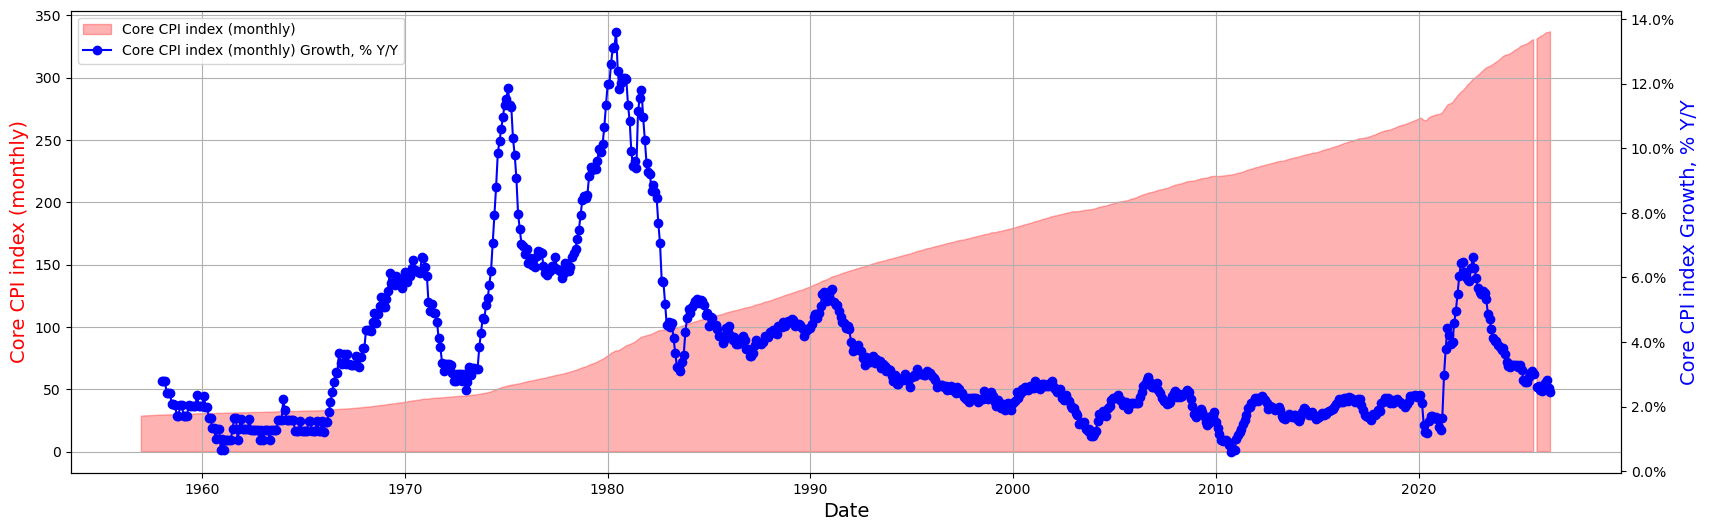

In [26]:
fig, ax = plt.subplots(figsize=(20, 6))
plt.grid(True)

# Plotting area under CPI
ax.fill_between(cpilfesl.index, cpilfesl.CPILFESL, color="red", alpha=0.3, label="Core CPI index (monthly)")

# Creating a secondary y-axis for CPI growth percentage
ax2 = ax.twinx()
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax2.plot(cpilfesl.cpi_core_yoy, color="blue", marker="o", label="Core CPI index (monthly) Growth, % Y/Y")

# Setting labels and title
ax.set_xlabel("Date", fontsize=14)
ax.set_ylabel("Core CPI index (monthly)", color="red", fontsize=14)
ax2.set_ylabel("Core CPI index Growth, % Y/Y", color="blue", fontsize=14)

# Adding legend
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.show()

## 1.3 Interest rates

In [27]:
# Fed rate https://fred.stlouisfed.org/series/FEDFUNDS
fedfunds = pdr.DataReader("FEDFUNDS", "fred", start=start)
fedfunds.tail(10)

,FEDFUNDS
DATE,
2025-11-01,3.88
2025-12-01,3.72
2026-01-01,3.64
2026-02-01,3.64
2026-03-01,3.64
2026-04-01,3.64
2026-05-01,3.63
2026-06-01,3.63
2026-07-01,3.63


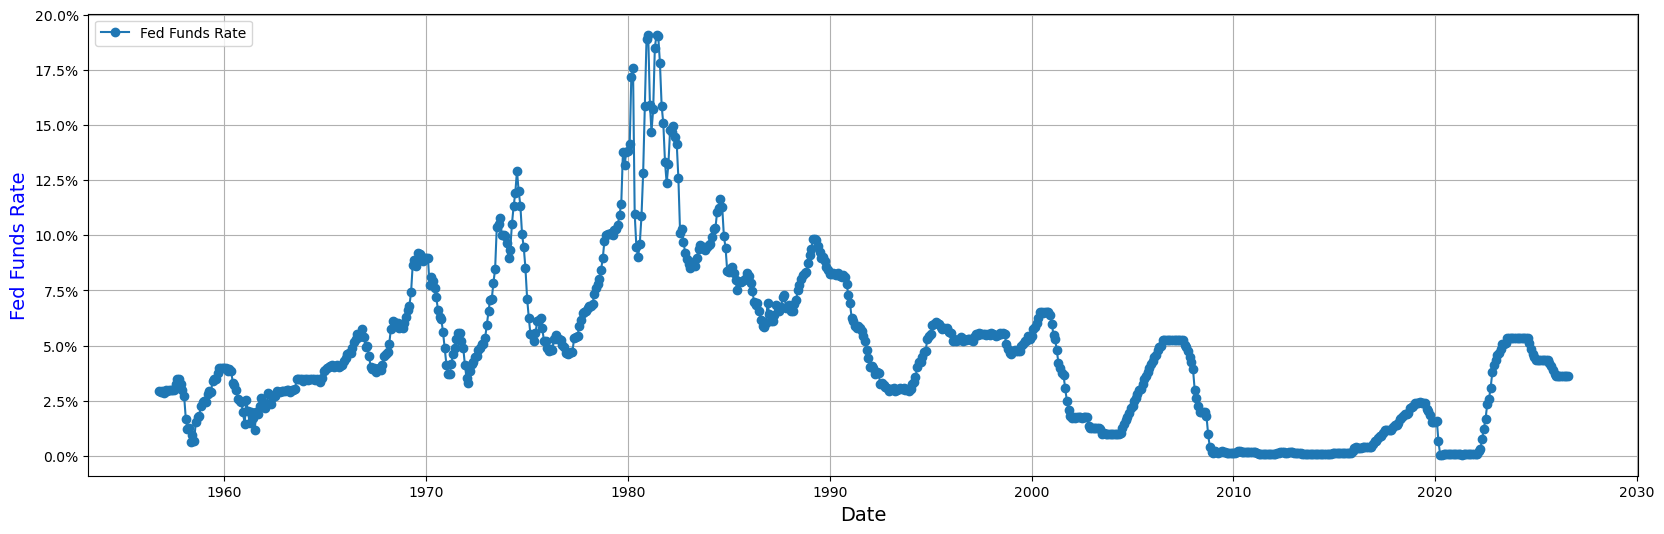

In [28]:
# Fed Funds
fig, ax = plt.subplots(figsize=(20, 6))
plt.grid(True)

# Plotting area under US potential GDP curve
# ax.fill_between(fedfunds.index, fedfunds.FEDFUNDS, color="red", alpha=0.3, label="Core CPI index (monthly)")

# # Creating a secondary y-axis for GDP growth percentage
# ax2 = ax.twinx()
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.plot(fedfunds.index, fedfunds.FEDFUNDS/100, marker="o", label="Fed Funds Rate")

# Setting labels and title
ax.set_xlabel("Date", fontsize=14)
ax.set_ylabel("Fed Funds Rate", color="blue", fontsize=14)

# Adding legend
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='upper left')

plt.show()

In [29]:
# https://fred.stlouisfed.org/series/DGS1
dgs1 = pdr.DataReader("DGS1", "fred", start=start)
dgs1.tail()

,DGS1
DATE,
2026-08-31,4.16
2026-09-01,4.18
2026-09-02,4.16
2026-09-03,4.11
2026-09-04,4.13


Other rates for US Treasury: https://fred.stlouisfed.org/categories/115  
* https://fred.stlouisfed.org/series/DGS2
* https://fred.stlouisfed.org/series/DGS3
* https://fred.stlouisfed.org/series/DGS5
* https://fred.stlouisfed.org/series/DGS10
...

In [30]:
# https://fred.stlouisfed.org/series/DGS5
dgs5 = pdr.DataReader("DGS5", "fred", start=start)
dgs5.tail()

,DGS5
DATE,
2026-08-31,4.49
2026-09-01,4.55
2026-09-02,4.54
2026-09-03,4.52
2026-09-04,4.54


## 1.4 SNP500

In [31]:
import yfinance as yf

# Other indexes: https://stooq.com/t/ ; https://stooq.com/t/?i=510  --main indexes
# USED TO BE ABLE TO GET DATA FROM STOOQ USING PDR - NOW, WE USE YAHOO FINANCE
# https://pandas-datareader.readthedocs.io/en/latest/remote_data.html


# SPX= S&P500
ticker_obj = yf.Ticker("^SPX")
spx_index = ticker_obj.history(start=start, end=end)
spx_index.tail()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-08-31 00:00:00-04:00,7697.520020,7697.520020,7665.060059,7686.140137,5386090000,0.0,0.0
2026-09-01 00:00:00-04:00,7635.470215,7663.629883,7611.200195,7631.470215,4858180000,0.0,0.0
2026-09-02 00:00:00-04:00,7634.580078,7681.189941,7633.620117,7666.600098,4738910000,0.0,0.0
2026-09-03 00:00:00-04:00,7686.709961,7756.759766,7686.709961,7747.709961,4726400000,0.0,0.0
2026-09-04 00:00:00-04:00,7750.189941,7750.189941,7706.120117,7718.600098,4103570000,0.0,0.0


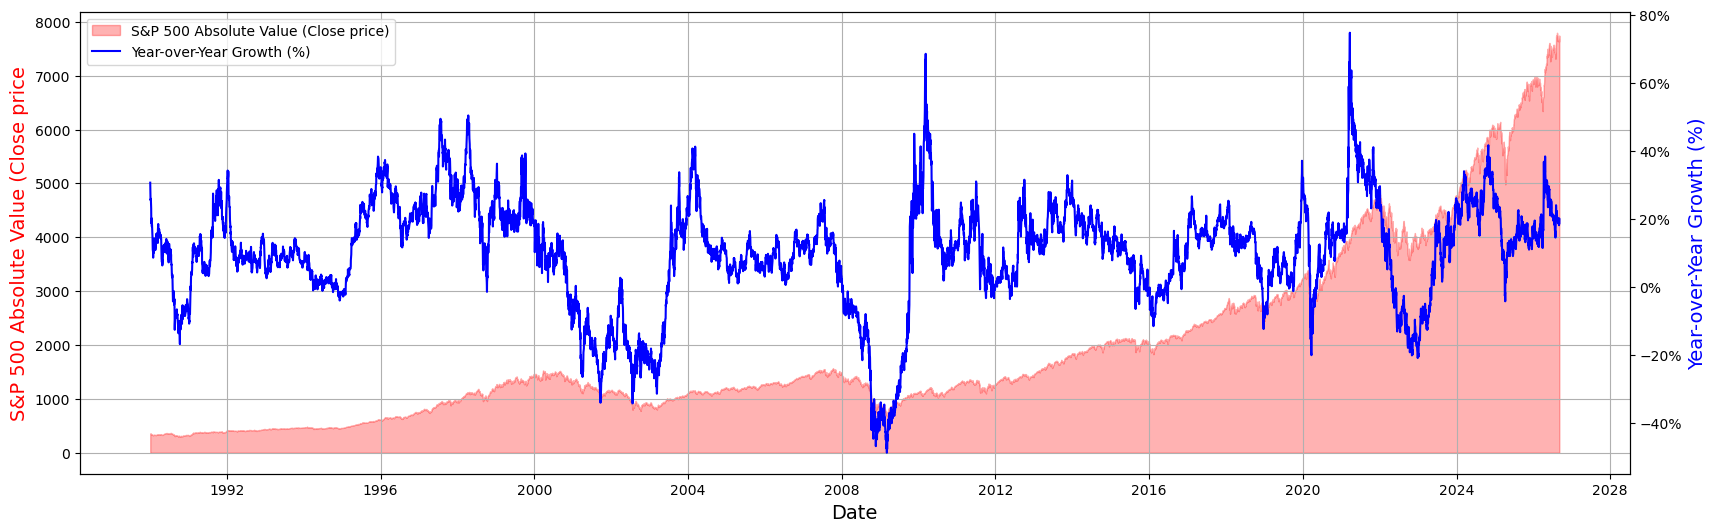

In [32]:
spx_index['spx_yoy'] = (spx_index.Close / spx_index.Close.shift(252)) - 1

# Re-truncate the DataFrame after recalculating 'spx_yoy' to ensure data consistency
spx_truncated = spx_index[spx_index.index>='1990-01-01']

# S&P500 abs. vs. relative growth
fig, ax = plt.subplots(figsize=(20, 6))
plt.grid(True)

# Plotting area under S&P 500 Close price
ax.fill_between(spx_truncated.index, spx_truncated.Close, color="red", alpha=0.3, label="S&P 500 Absolute Value (Close price)")

# Creating a secondary y-axis for S&P 500 year-over-year growth percentage
ax2 = ax.twinx()
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax2.plot(spx_truncated.spx_yoy,
         color="blue",
        #  marker=".",
         label="Year-over-Year Growth (%)")

# Setting labels and title
ax.set_xlabel("Date", fontsize=14)
ax.set_ylabel("S&P 500 Absolute Value (Close price", color="red", fontsize=14)
ax2.set_ylabel("Year-over-Year Growth (%)", color="blue", fontsize=14)

# Adding legend
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.show()

# 2) Data Sources for Stocks

## 2.1 OHLCV data daily - INDEXES

In [33]:
# INDEXES from Yahoo Finance
# DAX index (XETRA - XETRA Delayed Price. Currency in EUR)
# WEB: https://finance.yahoo.com/quote/%5EGDAXI
# Option 1: dax_daily = yf.download(tickers = ["^GDAXI"],
#                      period = "max",
#                      interval = "1d")

# Option 2 (preferred):
# Download data with Adj Close for more accurate price reflections
ticker_obj = yf.Ticker("^GDAXI")
dax_daily = ticker_obj.history(start = start)

In [34]:
dax_daily.tail()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-09-01 00:00:00+02:00,26150.750000,26206.130859,25916.759766,25970.109375,48552400,0.0,0.0
2026-09-02 00:00:00+02:00,25886.669922,25924.210938,25727.929688,25839.330078,47864100,0.0,0.0
2026-09-03 00:00:00+02:00,25840.919922,26007.789062,25784.839844,26003.320312,50330000,0.0,0.0
2026-09-04 00:00:00+02:00,25985.859375,26167.929688,25958.699219,26046.400391,47990000,0.0,0.0
2026-09-07 00:00:00+02:00,26039.539062,26069.990234,25919.609375,26006.529297,35638000,0.0,0.0


In [35]:
# normally 252 trading days
dax_daily['adj_close_last_year'] = dax_daily['Close'].shift(252)
dax_daily['yoy_growth'] = dax_daily['Close'] / dax_daily['adj_close_last_year'] -1

In [36]:
dax_daily

,Open,High,Low,Close,Volume,Dividends,Stock Splits,adj_close_last_year,yoy_growth
Date,,,,,,,,,
1987-12-30 00:00:00+01:00,1005.190002,1005.190002,1005.190002,1005.190002,0,0.0,0.0,NaN,NaN
1988-01-04 00:00:00+01:00,956.489990,956.489990,956.489990,956.489990,0,0.0,0.0,NaN,NaN
1988-01-05 00:00:00+01:00,996.099976,996.099976,996.099976,996.099976,0,0.0,0.0,NaN,NaN
1988-01-06 00:00:00+01:00,1006.010010,1006.010010,1006.010010,1006.010010,0,0.0,0.0,NaN,NaN
1988-01-07 00:00:00+01:00,1014.469971,1014.469971,1014.469971,1014.469971,0,0.0,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...
2026-09-01 00:00:00+02:00,26150.750000,26206.130859,25916.759766,25970.109375,48552400,0.0,0.0,23487.330078,0.105707
2026-09-02 00:00:00+02:00,25886.669922,25924.210938,25727.929688,25839.330078,47864100,0.0,0.0,23594.800781,0.095128
2026-09-03 00:00:00+02:00,25840.919922,26007.789062,25784.839844,26003.320312,50330000,0.0,0.0,23770.330078,0.093940


<Axes: xlabel='Date'>

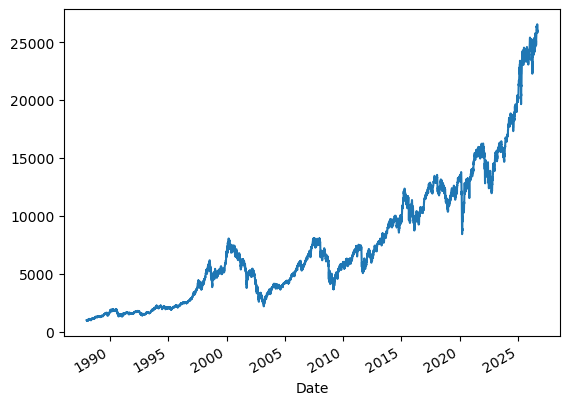

In [37]:
dax_daily['Close'].plot.line()

In [38]:
# delayed 15 min : https://finance.yahoo.com/quote/%5ESPX/
# S&P 500 INDEX : Chicago Options - Chicago Options Delayed Price. Currency in USD
ticker_obj = yf.Ticker("^SPX")
snp500_daily = ticker_obj.history(start = start, interval = "1d")

# old version:
# snp500_daily = yf.download(tickers = "^SPX",
#                      period = "max",
#                      interval = "1d")

In [39]:
snp500_daily.tail()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-09-01 00:00:00-04:00,7635.470215,7663.629883,7611.200195,7631.470215,4858180000,0.0,0.0
2026-09-02 00:00:00-04:00,7634.580078,7681.189941,7633.620117,7666.600098,4738910000,0.0,0.0
2026-09-03 00:00:00-04:00,7686.709961,7756.759766,7686.709961,7747.709961,4726400000,0.0,0.0
2026-09-04 00:00:00-04:00,7750.189941,7750.189941,7706.120117,7718.600098,4103570000,0.0,0.0
2026-09-08 00:00:00-04:00,7717.810059,7717.810059,7666.990234,7673.520020,2954551736,0.0,0.0


In [40]:
# https://finance.yahoo.com/quote/%5EGSPC/
# SNP - SNP Real Time Price. Currency in USD
# https://www.investopedia.com/insights/introduction-to-stock-market-indices/

ticker_obj = yf.Ticker("^GSPC")
snp500_daily_non_delayed = ticker_obj.history(start = start, interval = "1d")

# old version:
# snp500_daily_non_delayed = yf.download(tickers = "^GSPC",
#                      period = "max",
#                      interval = "1d")

In [41]:
snp500_daily_non_delayed.tail()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-09-01 00:00:00-04:00,7635.470215,7663.629883,7611.200195,7631.470215,4858180000,0.0,0.0
2026-09-02 00:00:00-04:00,7634.580078,7681.189941,7633.620117,7666.600098,4738910000,0.0,0.0
2026-09-03 00:00:00-04:00,7686.709961,7756.759766,7686.709961,7747.709961,4726400000,0.0,0.0
2026-09-04 00:00:00-04:00,7750.189941,7750.189941,7706.120117,7718.600098,4103570000,0.0,0.0
2026-09-08 00:00:00-04:00,7717.810059,7717.810059,7666.990234,7673.520020,2922644000,0.0,0.0


In [42]:
# Dow Jones Industrial Average: https://finance.yahoo.com/quote/%5EDJI?.tsrc=fin-srch

ticker_obj = yf.Ticker("^DJI")
dji_daily = ticker_obj.history(start = start, interval = "1d")

# dji_daily = yf.download(tickers = "^DJI",
#                      period = "max",
#                      interval = "1d")

## 2.2 OHLCV data daily - ETFs

In [43]:
# https://finance.yahoo.com/quote/VOO?.tsrc=fin-srch

ticker_obj = yf.Ticker("VOO")
voo_etf = ticker_obj.history(start = start, interval = "1d")

# voo_etf = yf.download(tickers = "VOO",
#                      period = "max",
#                      interval = "1d")


In [44]:
voo_etf.tail()

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
Date,,,,,,,,
2026-09-01 00:00:00-04:00,700.450012,702.909973,698.140015,700.280029,6486900,0.0,0.0,0.0
2026-09-02 00:00:00-04:00,700.849976,704.530029,700.179993,703.409973,7742300,0.0,0.0,0.0
2026-09-03 00:00:00-04:00,705.820007,711.520020,705.510010,710.719971,8585400,0.0,0.0,0.0
2026-09-04 00:00:00-04:00,709.719971,710.450012,706.900024,708.010010,6806600,0.0,0.0,0.0
2026-09-08 00:00:00-04:00,NaN,NaN,NaN,NaN,7807657,0.0,0.0,0.0


In [45]:
# ETFs
# WisdomTree India Earnings Fund (EPI)
# NYSEArca - Nasdaq Real Time Price. Currency in USD
# WEB: https://finance.yahoo.com/quote/EPI/history?p=EPI

ticker_obj = yf.Ticker("EPI")
epi_etf_daily = ticker_obj.history(start = start, interval = "1d")

# epi_etf_daily = yf.download(tickers = "EPI",
#                      period = "max",
#                      interval = "1d")

In [46]:
epi_etf_daily.head()
print(epi_etf_daily.shape)

(4663, 8)


In [47]:
# find dividends impact on Close vs. Adj.Close
epi_etf_daily[epi_etf_daily.Dividends>0].tail()

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
Date,,,,,,,,
2021-12-27 00:00:00-05:00,33.577710,33.801812,33.577710,33.764462,379100,0.192,0.0,0.0
2022-03-25 00:00:00-04:00,33.563275,33.666313,33.432129,33.666313,584400,0.115,0.0,0.0
2022-06-24 00:00:00-04:00,29.420327,29.778748,29.370547,29.768791,387900,1.845,0.0,0.0
2023-06-26 00:00:00-04:00,34.020314,34.070182,33.960471,33.990395,634600,0.060,0.0,0.0
2024-12-26 00:00:00-05:00,45.840000,45.840000,45.700001,45.820000,685600,0.121,0.0,0.0


In [48]:
epi_etf_daily[(epi_etf_daily.index >='2024-12-23') & (epi_etf_daily.index <='2024-12-28')]

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
Date,,,,,,,,
2024-12-23 00:00:00-05:00,45.609761,45.879052,45.609761,45.869080,630400,0.000,0.0,0.0
2024-12-24 00:00:00-05:00,45.719475,45.928922,45.709503,45.899002,277100,0.000,0.0,0.0
2024-12-26 00:00:00-05:00,45.840000,45.840000,45.700001,45.820000,685600,0.121,0.0,0.0
2024-12-27 00:00:00-05:00,45.570000,45.650002,45.500000,45.639999,774900,0.000,0.0,0.0


In [49]:
# find dividends - diff for Close vs. Adj Close
# Open/Close for 06-25 diff is close to divs = 1.845 (~1.58 for Open and 1.3 for Close)
# HELP: https://help.yahoo.com/kb/SLN28256.html#:~:text=Adjusted%20close%20is%20the%20closing,Security%20Prices%20(CRSP)%20standards.
epi_etf_daily[(epi_etf_daily.index >='2024-12-23') & (epi_etf_daily.index <='2024-12-28')]

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
Date,,,,,,,,
2024-12-23 00:00:00-05:00,45.609761,45.879052,45.609761,45.869080,630400,0.000,0.0,0.0
2024-12-24 00:00:00-05:00,45.719475,45.928922,45.709503,45.899002,277100,0.000,0.0,0.0
2024-12-26 00:00:00-05:00,45.840000,45.840000,45.700001,45.820000,685600,0.121,0.0,0.0
2024-12-27 00:00:00-05:00,45.570000,45.650002,45.500000,45.639999,774900,0.000,0.0,0.0


In [50]:
# Previous option : no Div. dates , same stats
epi_etf_daily2 = yf.download(tickers = "EPI",
                     period = "max",
                     interval = "1d")

[*********************100%***********************]  1 of 1 completed


In [51]:
epi_etf_daily2[epi_etf_daily2.index>='2024-12-23'].head()

Price,Close,High,Low,Open,Volume
Ticker,EPI,EPI,EPI,EPI,EPI
Date,,,,,
2024-12-23,45.869080,45.879052,45.609761,45.609761,630400
2024-12-24,45.899002,45.928922,45.709503,45.719475,277100
2024-12-26,45.820000,45.840000,45.700001,45.840000,685600
2024-12-27,45.639999,45.650002,45.500000,45.570000,774900
2024-12-30,45.090000,45.180000,44.980000,45.180000,1442100


<Axes: title={'center': "EPI's etf stock price"}, xlabel='Date'>

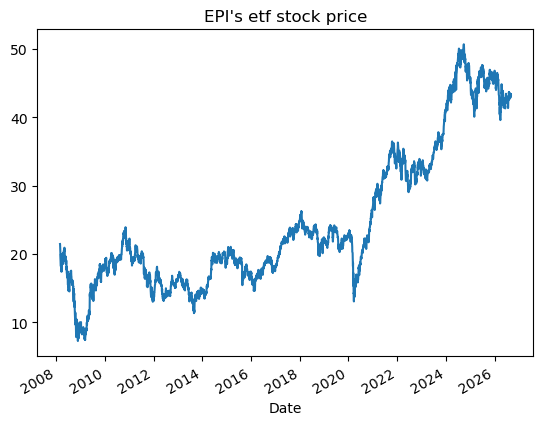

In [52]:
# About yFinance: https://zoo.cs.yale.edu/classes/cs458/lectures/yfinance.html

epi_etf_daily['Close'].plot(title="EPI's etf stock price")

In [53]:
# get actions, incl. dividends - as a dataFrame
epi = yf.Ticker('EPI')
epi.get_actions()

,Dividends
Date,
2008-12-22 00:00:00-05:00,0.091
2009-03-23 00:00:00-04:00,0.007
2009-06-22 00:00:00-04:00,0.002
2009-09-21 00:00:00-04:00,0.045
2009-12-21 00:00:00-05:00,0.006
2010-06-28 00:00:00-04:00,0.065
2010-09-20 00:00:00-04:00,0.065
2010-12-22 00:00:00-05:00,0.013
2011-06-22 00:00:00-04:00,0.062


In [54]:
# get dividends as Series
epi.get_dividends()

Date
2008-12-22 09:30:00-05:00    0.091
2009-03-23 09:30:00-04:00    0.007
2009-06-22 09:30:00-04:00    0.002
2009-09-21 09:30:00-04:00    0.045
2009-12-21 09:30:00-05:00    0.006
2010-06-28 09:30:00-04:00    0.065
2010-09-20 09:30:00-04:00    0.065
2010-12-22 09:30:00-05:00    0.013
2011-06-22 09:30:00-04:00    0.062
2011-09-26 09:30:00-04:00    0.098
2012-03-26 09:30:00-04:00    0.010
2012-06-25 09:30:00-04:00    0.045
2012-09-24 09:30:00-04:00    0.083
2012-12-24 09:30:00-05:00    0.024
2013-06-24 09:30:00-04:00    0.068
2013-09-23 09:30:00-04:00    0.063
2014-03-24 09:30:00-04:00    0.099
2014-06-23 09:30:00-04:00    0.059
2014-09-22 09:30:00-04:00    0.068
2015-03-23 09:30:00-04:00    0.031
2015-06-22 09:30:00-04:00    0.067
2015-09-21 09:30:00-04:00    0.116
2015-12-21 09:30:00-05:00    0.024
2016-03-21 09:30:00-04:00    0.010
2016-06-20 09:30:00-04:00    0.125
2016-09-26 09:30:00-04:00    0.070
2016-12-23 09:30:00-05:00    0.006
2017-03-27 09:30:00-04:00    0.075
2017-06-26 09:3

In [55]:
# India's stock example
# https://www.nseindia.com/market-data/live-equity-market
EICHERMOT = yf.download(tickers = "EICHERMOT.NS",
                     period = "max",
                     interval = "1d")

[*********************100%***********************]  1 of 1 completed


In [56]:
EICHERMOT

Price,Close,High,Low,Open,Volume
Ticker,EICHERMOT.NS,EICHERMOT.NS,EICHERMOT.NS,EICHERMOT.NS,EICHERMOT.NS
Date,,,,,
1996-01-01,1.119486,1.119486,1.119486,1.119486,22000
1996-01-02,1.122597,1.131926,1.119487,1.119487,31000
1996-01-03,1.135035,1.135035,1.135035,1.135035,11000
1996-01-04,1.135035,1.135035,1.119487,1.119487,16000
1996-01-05,1.119486,1.135035,1.100828,1.135035,6000
...,...,...,...,...,...
2026-09-01,7970.000000,8052.000000,7860.000000,7975.000000,760133
2026-09-02,7711.500000,7893.000000,7507.500000,7860.000000,1117588


## 2.3 Paid data - Poligon.io (news endpoint) and Alpha Vantage

In [57]:
# [Polygon.io] Please read the article (section "Polygon.io News API"): https://pythoninvest.com/long-read/chatgpt-api-for-financial-news-summarization
# Endpoint: https://polygon.io/docs/stocks/get_v2_reference_news

In [58]:
# [Alpha Vantage] Please read the article (section "Data Sources"): https://pythoninvest.com/long-read/stock-screening-using-paid-data
# Endpoint: https://www.alphavantage.co/documentation/#fundamentals

## 2.4 Macroeconomics

* some indicator examples: gold reserves vs. volatility

In [59]:
# Gold reserves excl. gold for China
# https://fred.stlouisfed.org/series/TRESEGCNM052N

In [60]:
gold_reserves = pdr.DataReader("TRESEGCNM052N", "fred", start=start)

<Axes: xlabel='DATE'>

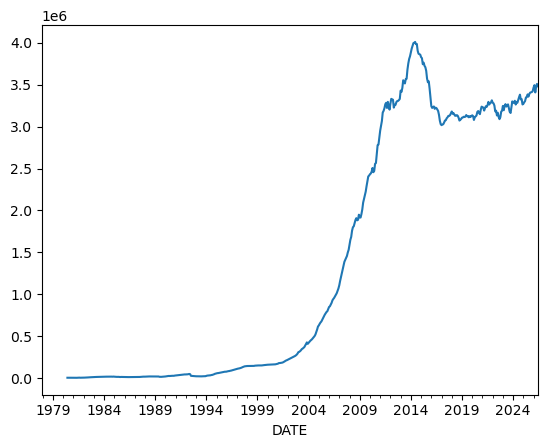

In [61]:
gold_reserves.TRESEGCNM052N.plot.line()

In [62]:
#  CBOE Gold ETF Volatility Index (GVZCLS)
# https://fred.stlouisfed.org/series/GVZCLS
gold_volatility = pdr.DataReader("GVZCLS", "fred", start=start)

<Axes: xlabel='DATE'>

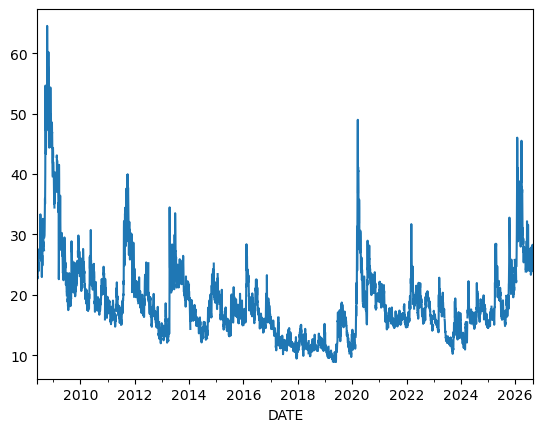

In [63]:
gold_volatility.GVZCLS.plot.line()

In [64]:
#  Crude Oil Prices: West Texas Intermediate (WTI) - Cushing, Oklahoma (DCOILWTICO)
# https://fred.stlouisfed.org/series/DCOILWTICO
oil_wti = pdr.DataReader("DCOILWTICO", "fred", start=start)

<Axes: xlabel='DATE'>

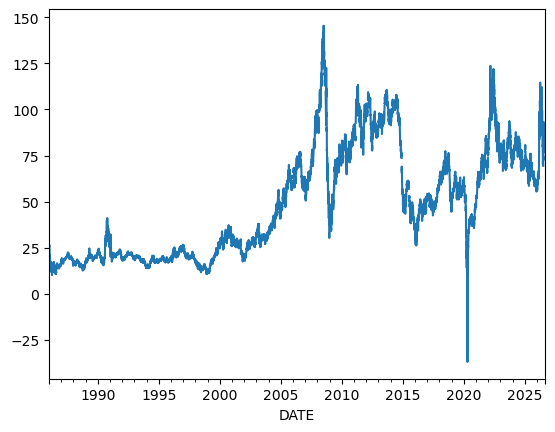

In [65]:
# there is a bug in the data? negative price?
oil_wti.DCOILWTICO.plot.line()

In [66]:
# Crude Oil Prices: Brent - Europe (DCOILBRENTEU)
# https://fred.stlouisfed.org/series/DCOILBRENTEU
oil_brent = pdr.DataReader("DCOILBRENTEU", "fred", start=start)

<Axes: xlabel='DATE'>

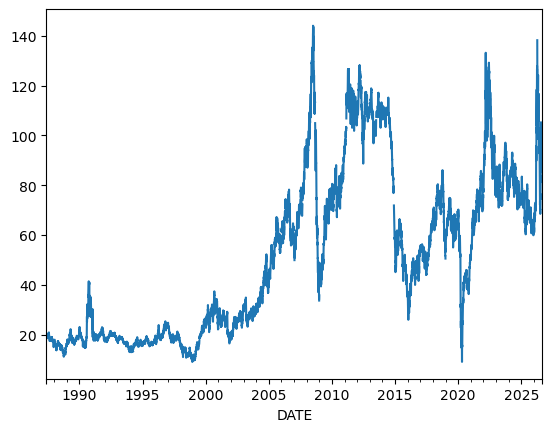

In [67]:
oil_brent.DCOILBRENTEU.plot.line()

In [68]:
# Web Scraping for Macro
# can't call directly via pd.read_html() as it returns 403 (forbidden) --> need to do a bit of work, but still no Selenium
# https://tradingeconomics.com/united-states/indicators
import requests
from bs4 import BeautifulSoup


url = "https://tradingeconomics.com/united-states/indicators"
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3"
}

response = requests.get(url, headers=headers)

In [69]:

# Check if the request was successful (status code 200)
if response.status_code == 200:
    # Parse the HTML content of the webpage
    soup = BeautifulSoup(response.content, "html.parser")

    # You need to be able to find this table tag and read all behind it
    # Find the div with class "table-responsive"
    table_div = soup.find("div", class_="table-responsive")

    # Extract the table within the div
    table = table_div.find("table")

    # Use pandas to read the table into a DataFrame
    df = pd.read_html(str(table))[0]  # Assuming there's only one table, otherwise, loop through the list

    # Display the DataFrame
    print(df)
else:
    print("Failed to retrieve data from the webpage.")

                  Unnamed: 0     Last  Previous  Highest    Lowest  \
0                   Currency    98.74     98.87   165.00     70.70   
1               Stock Market  7673.00   7674.00  7817.00      4.40   
2            GDP Growth Rate     1.50      2.10    34.90    -28.00   
3     GDP Annual Growth Rate     2.10      2.70    13.40     -7.40   
4          Unemployment Rate     4.10      4.10    14.80      2.50   
5          Non Farm Payrolls   162.00     21.00  4631.00 -20469.00   
6             Inflation Rate     3.40      3.50    23.70    -15.80   
7         Inflation Rate MoM     0.10     -0.40     2.00     -1.80   
8              Interest Rate     3.75      3.75    20.00      0.25   
9           Balance of Trade   -88.58    -71.18     1.95   -133.00   
10           Current Account  -227.00   -221.00     9.96   -438.00   
11    Current Account to GDP    -3.60     -4.00     0.20     -6.00   
12    Government Debt to GDP   123.00    122.00   126.00     31.80   
13         Governmen

C:\Users\Siddharth\AppData\Local\Temp\ipykernel_19424\51921383.py:14: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.read_html(str(table))[0]  # Assuming there's only one table, otherwise, loop through the list


In [70]:
df

,Unnamed: 0,Last,Previous,Highest,Lowest,Unnamed: 5,Unnamed: 6
0,Currency,98.74,98.87,165.00,70.70,NaN,Sep/26
1,Stock Market,7673.00,7674.00,7817.00,4.40,points,Sep/26
2,GDP Growth Rate,1.50,2.10,34.90,-28.00,percent,Jun/26
3,GDP Annual Growth Rate,2.10,2.70,13.40,-7.40,percent,Jun/26
4,Unemployment Rate,4.10,4.10,14.80,2.50,percent,Aug/26
5,Non Farm Payrolls,162.00,21.00,4631.00,-20469.00,Thousand,Aug/26
6,Inflation Rate,3.40,3.50,23.70,-15.80,percent,Jul/26
7,Inflation Rate MoM,0.10,-0.40,2.00,-1.80,percent,Jul/26
8,Interest Rate,3.75,3.75,20.00,0.25,percent,Aug/26
9,Balance of Trade,-88.58,-71.18,1.95,-133.00,USD Billion,Jul/26


## 2.5) Financial reporting - EDGAR (in Yahoo)

In [71]:
# let's check for NVDA
nvda =  yf.Ticker('NVDA')

In [72]:
# yearly financials for the last 4 years
nvda.financials


,2026-01-31,2025-01-31,2024-01-31,2023-01-31,2022-01-31
Tax Effect Of Unusual Items,0.000000e+00,0.000000e+00,0.000000e+00,-2.841300e+08,NaN
Tax Rate For Calcs,1.511700e-01,1.326490e-01,1.200000e-01,2.100000e-01,NaN
Normalized EBITDA,1.445520e+11,8.613700e+10,3.558300e+10,7.339000e+09,NaN
Total Unusual Items,NaN,0.000000e+00,0.000000e+00,-1.353000e+09,0.0
Total Unusual Items Excluding Goodwill,NaN,0.000000e+00,0.000000e+00,-1.353000e+09,0.0
Net Income From Continuing Operation Net Minority Interest,1.200670e+11,7.288000e+10,2.976000e+10,4.368000e+09,NaN
Reconciled Depreciation,2.843000e+09,1.864000e+09,1.508000e+09,1.543000e+09,NaN
Reconciled Cost Of Revenue,6.247500e+10,3.263900e+10,1.662100e+10,1.161800e+10,NaN
EBITDA,1.445520e+11,8.613700e+10,3.558300e+10,5.986000e+09,NaN
EBIT,1.417090e+11,8.427300e+10,3.407500e+10,4.443000e+09,NaN


In [73]:
# balance sheet
nvda.balance_sheet

,2026-01-31,2025-01-31,2024-01-31,2023-01-31,2022-01-31
Ordinary Shares Number,2.430400e+10,2.447700e+10,2.464000e+10,2.466137e+10,NaN
Share Issued,2.430400e+10,2.447700e+10,2.464000e+10,2.466137e+10,NaN
Net Debt,NaN,NaN,2.429000e+09,7.564000e+09,8.956000e+09
Total Debt,1.104000e+10,9.982000e+09,1.105600e+10,1.203100e+10,NaN
Tangible Book Value,1.331550e+11,7.333200e+10,3.743600e+10,1.605300e+10,NaN
...,...,...,...,...,...
Receivables,3.846600e+10,2.306500e+10,9.999000e+09,3.827000e+09,NaN
Accounts Receivable,3.846600e+10,2.306500e+10,9.999000e+09,3.827000e+09,NaN
Cash Cash Equivalents And Short Term Investments,6.255600e+10,4.321000e+10,2.598400e+10,1.329600e+10,NaN
Other Short Term Investments,5.195100e+10,3.462100e+10,1.870400e+10,9.907000e+09,NaN


In [74]:
# Basic info:
nvda.fast_info

lazy-loading dict with keys = ['currency', 'dayHigh', 'dayLow', 'exchange', 'fiftyDayAverage', 'lastPrice', 'lastVolume', 'marketCap', 'open', 'previousClose', 'quoteType', 'regularMarketPreviousClose', 'shares', 'tenDayAverageVolume', 'threeMonthAverageVolume', 'timezone', 'twoHundredDayAverage', 'yearChange', 'yearHigh', 'yearLow']

In [75]:
# marketCap is quite useful, but don't know when it was updated? Daily?
nvda.fast_info['marketCap']/1e9

5450.70231

In [76]:
# read this article for full info: https://zoo.cs.yale.edu/classes/cs458/lectures/yfinance.html

## 2.6 Web Scraping - company info for clustering

In [77]:
# ask chatGPT: emulate clicking the link and downloading the content
import requests
from bs4 import BeautifulSoup

# URL of the webpage
url = "https://companiesmarketcap.com/"

# Define headers with a user-agent to mimic a web browser
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3"
}

# Send a GET request to the URL with headers
response = requests.get(url, headers=headers)

# Check if the request was successful (status code 200)
if response.status_code == 200:
    # Parse the HTML content of the webpage
    soup = BeautifulSoup(response.content, "html.parser")

    # Find the download link within the webpage
    download_link = soup.find("a", {"rel": "nofollow", "href": "?download=csv"})

    # If the download link is found
    if download_link:
        # Extract the href attribute which contains the actual download link
        download_url = 'https://companiesmarketcap.com/'+download_link["href"]

        # Download the CSV file using the obtained download URL
        download_response = requests.get(download_url, headers=headers)

        # Check if the download request was successful
        if download_response.status_code == 200:
            # Save the content of the response to a local file
            with open("global_stocks.csv", "wb") as f:
                f.write(download_response.content)
            print("CSV file downloaded successfully.")
        else:
            print("Failed to download the CSV file.")
    else:
        print("Download link not found on the webpage.")
else:
    print("Failed to retrieve data from the webpage.")

CSV file downloaded successfully.


In [80]:
global_stocks = pd.read_csv("global_stocks.csv")

In [81]:
global_stocks['marketcap_b_usd'] = global_stocks.marketcap/1e9

In [82]:
global_stocks.head(10)

,Rank,Name,Symbol,marketcap,price (USD),country,marketcap_b_usd
0,1,NVIDIA,NVDA,5450701996032,225.73000,United States,5450.701996
1,2,Apple,AAPL,4614971719680,316.22000,United States,4614.971720
2,3,Alphabet (Google),GOOG,4101675679744,335.38000,United States,4101.675680
3,4,Microsoft,MSFT,3667848331264,493.95000,United States,3667.848331
4,5,Amazon,AMZN,2771758874624,256.97000,United States,2771.758875
5,6,TSMC,TSM,2276862197760,439.00000,Taiwan,2276.862198
6,7,SpaceX,SPCX,2023007846400,153.47000,United States,2023.007846
7,8,Broadcom,AVGO,1753453821952,368.56000,United States,1753.453822
8,9,Saudi Aramco,2222.SR,1678856552070,6.94008,Saudi Arabia,1678.856552
9,10,Meta Platforms (Facebook),META,1562844069888,613.48000,United States,1562.844070


In [83]:
global_stocks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11299 entries, 0 to 11298
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Rank             11299 non-null  int64  
 1   Name             11299 non-null  object 
 2   Symbol           11298 non-null  object 
 3   marketcap        11299 non-null  int64  
 4   price (USD)      11299 non-null  float64
 5   country          11299 non-null  object 
 6   marketcap_b_usd  11299 non-null  float64
dtypes: float64(2), int64(2), object(3)
memory usage: 618.0+ KB
